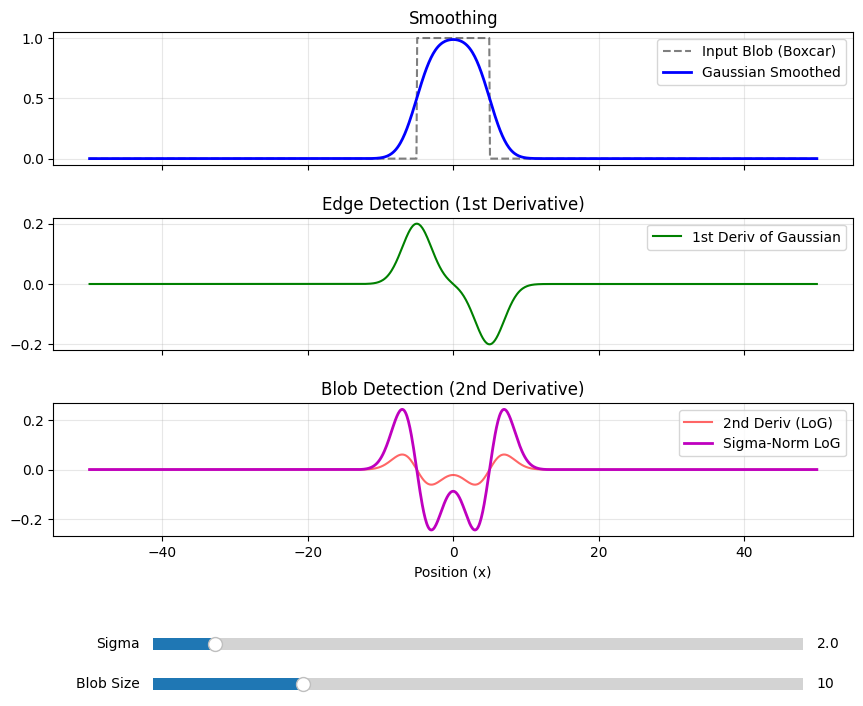

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# -----------------------------------------------------------------------------
# 1. Setup the Domain and Functions
# -----------------------------------------------------------------------------

# Resolution of the simulation
points = 1000
limit = 50
x = np.linspace(-limit, limit, points)
dx = x[1] - x[0]

def get_blob(size):
    """
    Creates a 1D Boxcar (rectangular) blob.
    """
    y = np.zeros_like(x)
    # Create a simple step/box function centered at 0
    mask = np.abs(x) <= (size / 2.0)
    y[mask] = 1.0
    return y

def get_kernels(sigma):
    """
    Generates Gaussian, 1st Derivative, 2nd Derivative, and Normalized LoG kernels.
    """
    # Create a kernel grid sufficient to hold the gaussian tails
    k_radius = int(4 * sigma) 
    # Ensure kernel grid matches the resolution of x
    k_x = np.arange(-k_radius, k_radius + dx, dx)
    
    # 1. Gaussian (G)
    # Normalization factor 1/(sqrt(2pi)*sigma)
    norm = 1.0 / (np.sqrt(2 * np.pi) * sigma)
    g = norm * np.exp(-(k_x**2) / (2 * sigma**2))
    
    # 2. Derivative of Gaussian (DoG)
    # dG/dx = -x/sigma^2 * G
    g_prime = -(k_x / sigma**2) * g
    
    # 3. Second Derivative of Gaussian (LoG - Laplacian of Gaussian)
    # d^2G/dx^2 = (x^2/sigma^4 - 1/sigma^2) * G
    g_double_prime = ((k_x**2 / sigma**4) - (1 / sigma**2)) * g
    
    # 4. Sigma Normalized LoG (Scale Normalized)
    # sigma^2 * (d^2G/dx^2)
    norm_log = (sigma**2) * g_double_prime
    
    return g, g_prime, g_double_prime, norm_log

# -----------------------------------------------------------------------------
# 2. Plotting Setup
# -----------------------------------------------------------------------------

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
plt.subplots_adjust(left=0.1, bottom=0.25, hspace=0.4)

# Initial Parameters
init_sigma = 2.0
init_size = 10.0

# Generate Initial Data
blob = get_blob(init_size)
kern_g, kern_d1, kern_d2, kern_nlog = get_kernels(init_sigma)

# Perform Convolutions (using 'same' to keep output size equal to input)
# We multiply by dx to approximate the continuous integral convolution
conv_g = np.convolve(blob, kern_g, mode='same') * dx
conv_d1 = np.convolve(blob, kern_d1, mode='same') * dx
conv_d2 = np.convolve(blob, kern_d2, mode='same') * dx
conv_nlog = np.convolve(blob, kern_nlog, mode='same') * dx

# --- Plot 1: Input & Gaussian Smoothing ---
l_blob, = ax1.plot(x, blob, 'k--', label='Input Blob (Boxcar)', alpha=0.5)
l_g, = ax1.plot(x, conv_g, 'b-', label='Gaussian Smoothed', linewidth=2)
ax1.set_title('Smoothing')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Plot 2: 1st Derivative (Edge Detection) ---
l_d1, = ax2.plot(x, conv_d1, 'g-', label='1st Deriv of Gaussian')
ax2.set_title('Edge Detection (1st Derivative)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# --- Plot 3: 2nd Derivative (Blob Detection) ---
l_d2, = ax3.plot(x, conv_d2, 'r-', label='2nd Deriv (LoG)', alpha=0.6)
l_nlog, = ax3.plot(x, conv_nlog, 'm-', linewidth=2, label='Sigma-Norm LoG')
ax3.set_title('Blob Detection (2nd Derivative)')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('Position (x)')

# -----------------------------------------------------------------------------
# 3. Sliders and Update Logic
# -----------------------------------------------------------------------------

# Axes for sliders [left, bottom, width, height]
ax_sigma = plt.axes([0.2, 0.1, 0.65, 0.03])
ax_size = plt.axes([0.2, 0.05, 0.65, 0.03])

slider_sigma = Slider(ax_sigma, 'Sigma', 0.1, 20.0, valinit=init_sigma)
slider_size = Slider(ax_size, 'Blob Size', 1.0, 40.0, valinit=init_size)

def update(val):
    # Get current slider values
    sigma = slider_sigma.val
    size = slider_size.val
    
    # Re-calculate
    new_blob = get_blob(size)
    k_g, k_d1, k_d2, k_nlog = get_kernels(sigma)
    
    # Re-convolve
    # Note: Multiplying by dx is important for integral approximation consistency
    res_g = np.convolve(new_blob, k_g, mode='same') * dx
    res_d1 = np.convolve(new_blob, k_d1, mode='same') * dx
    res_d2 = np.convolve(new_blob, k_d2, mode='same') * dx
    res_nlog = np.convolve(new_blob, k_nlog, mode='same') * dx
    
    # Update Plot Data
    l_blob.set_ydata(new_blob)
    l_g.set_ydata(res_g)
    
    l_d1.set_ydata(res_d1)
    
    l_d2.set_ydata(res_d2)
    l_nlog.set_ydata(res_nlog)
    
    # Rescale axes to fit new data amplitude
    ax1.relim(); ax1.autoscale_view()
    ax2.relim(); ax2.autoscale_view()
    ax3.relim(); ax3.autoscale_view()
    
    fig.canvas.draw_idle()

# Register the update function to the sliders
slider_sigma.on_changed(update)
slider_size.on_changed(update)

plt.show()